In [5]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

<h1 style="color:cyan; font-family:Arial;">1. Business Understanding</h1>

<h2 style="color:green; font-family:Arial;">🎯 Objectif</h2>

<p style="font-size:16px; font-family:Arial;">
L'objectif est d'améliorer la <strong>reconnaissance des émotions dans la parole</strong> en explorant des approches avancées de génération et de classification d'audio émotionnel, en reproduisant l’article :<br><br>
<em style="color:#8E44AD;"><strong>"A Generation of Enhanced Data by Variational Autoencoders and Diffusion Modeling"</strong></em>
</p>

<h3 style="color:#2E86C1; font-family:Arial;">📁 Jeux de données utilisés :</h3>
<ul style="font-size:16px; font-family:Arial;">
  <li><strong>EmoDB</strong> : corpus vocal émotionnel en <span style="color:#27AE60;">allemand</span></li>
  <li><strong>RAVDESS</strong> : corpus vocal émotionnel en <span style="color:#27AE60;">anglais</span></li>
</ul>


In [6]:
#Chemin vers RAVDESS
RAVDESS_PATH = "RAVDESS" # Remplacez par votre chemin
# Mapping pour RAVDESS (basé sur le nom de fichier, e.g., "03" = tristesse)
ravdess_emotion_map = {
   '01': 'neutral',
    #'02': 'calm', 
    '03': 'happy',
    '04': 'sad',
    '05': 'anger',
    '06': 'fear',    
    '07': 'disgust',
    #'08': 'surprised'

}

In [7]:
# Chemin vers EmoDB
EMODB_PATH = "EmoDB"     # Remplacez par votre chemin
# Mapping des émotions pour EmoDB (basé sur les noms de fichiers)
emodb_emotion_map ={
    'W': 'anger',# Colère
    #'L': 'boredom',# Ennui
    'E': 'disgust',# Dégoût
    'A': 'fear',# Peur
    'F': 'happy',# Joie
    'T': 'sad',# Tristesse
    'N': 'neutral',# Neutre
}


<h1 style="color:cyan; font-family:Arial;">2. Data Understanding</h1>

<h2 style="color:green; font-family:Arial;">📊 Présentation des jeux de données</h2>

<p style="font-size:16px; font-family:Arial;">
Dans cette étude, deux bases de données vocales émotionnelles sont utilisées pour entraîner et évaluer les modèles de reconnaissance d'émotions :
</p>

<ul style="font-size:16px; font-family:Arial;">
  <li><strong>EmoDB</strong> : 7 émotions, environ <strong>500</strong> enregistrements, échantillonnés à <code>16kHz</code> (resamplés à <code>22,025Hz</code>). Enregistrements réalisés par 10 locuteurs (5 hommes, 5 femmes) en <span style="color:#27AE60;">allemand</span>.</li>
  <li><strong>RAVDESS</strong> : 8 émotions (7 retenues), environ <strong>1400</strong> enregistrements, échantillonnés à <code>48kHz</code> (resamplés à <code>22,025Hz</code>). Données exprimées par 24 locuteurs (12 hommes, 12 femmes) en <span style="color:#27AE60;">anglais</span>.</li>
</ul>

<h2 style="color:green; font-family:Arial;">🎧 Format des données</h2>
<p style="font-size:16px; font-family:Arial;">
Toutes les données sont fournies au format <code>.wav</code>. Elles sont transformées en <strong style="color:#2980B9;">mel-spectrogrammes</strong> afin d'être exploitables par les modèles de deep learning, notamment les CNN comme <strong>ResNet50</strong>.
</p>

<h3 style="color:blue; font-family:Arial;">📌 Résumé</h3>
<table style="font-family:Arial; font-size:16px; border-collapse:collapse;" border="1">
  <thead style="background-color:blue;">
    <tr>
      <th style="padding:8px;">Base</th>
      <th style="padding:8px;">Émotions</th>
      <th style="padding:8px;">Langue</th>
      <th style="padding:8px;">Échantillonnage</th>
      <th style="padding:8px;">Locuteurs</th>
      <th style="padding:8px;">Nombre d'audios</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding:8px;">EmoDB</td>
      <td style="padding:8px;">7 (6 utilisées)</td>
      <td style="padding:8px;">Allemand</td>
      <td style="padding:8px;">16KHz</td>
      <td style="padding:8px;">10</td>
      <td style="padding:8px;">~500</td>
    </tr>
    <tr>
      <td style="padding:8px;">RAVDESS</td>
      <td style="padding:8px;">8 (6 utilisées)</td>
      <td style="padding:8px;">Anglais</td>
      <td style="padding:8px;">48KHz</td>
      <td style="padding:8px;">24</td>
      <td style="padding:8px;">~1400</td>
    </tr>
  </tbody>
</table>


In [8]:
def load_emodb(data_path):
    data = []
    for file in tqdm(os.listdir(data_path)):
        if file.endswith('.wav'):
            emotion_code = file[5]  # Ex: "a01a.wav" -> 'a' (5ème caractère = émotion)
            emotion = emodb_emotion_map.get(emotion_code, None)
            if emotion:
                file_path = os.path.join(data_path, file)
                data.append({'file': file_path, 'emotion': emotion})
    return pd.DataFrame(data)

In [9]:
def load_ravdess(data_path):
    data = []
    for actor_dir in tqdm(os.listdir(data_path)):
        actor_path = os.path.join(data_path, actor_dir)
        if os.path.isdir(actor_path):
            for file in os.listdir(actor_path):
                if file.endswith('.wav') :
                    parts = file.split('-')
                    emotion_code = parts[2]  # Ex: "03" = happy
                    emotion = ravdess_emotion_map.get(emotion_code, None)
                    if emotion:
                        file_path = os.path.join(actor_path, file)
                        data.append({'file': file_path, 'emotion': emotion})
    return pd.DataFrame(data)

In [ ]:
# Charger les données
emodb_df = load_emodb(EMODB_PATH)
ravdess_df = load_ravdess(RAVDESS_PATH)
# Concaténer les deux DataFrames
df = pd.concat([emodb_df, ravdess_df], ignore_index=True)
df.size, df.head()
df.to_csv('emotional_speech_dataset2.csv', index=False)


100%|██████████| 25/25 [00:00<00:00, 555.30it/s]


In [13]:
df.head()

,file,emotion
0,EmoDB\03a01Fa.wav,happy
1,EmoDB\03a01Nc.wav,neutral
2,EmoDB\03a01Wa.wav,anger
3,EmoDB\03a02Fc.wav,happy
4,EmoDB\03a02Nc.wav,neutral


In [16]:
df.describe()

,duration_sec
count,1510.000000
mean,3.438778
std,0.778566
min,1.225500
25%,3.203208
50%,3.570229
75%,3.837167
max,8.978250


In [11]:
# Afficher un aperçu
print(f"Nombre total d'échantillons : {len(df)}")
print(df['emotion'].value_counts())

Nombre total d'échantillons : 1510
emotion
anger      319
happy      263
fear       261
sad        254
disgust    238
neutral    175
Name: count, dtype: int64


In [12]:
print("Répartition des émotions dans EmoDB :")
print(emodb_df['emotion'].value_counts())
print("Répartition des émotions dans R :")
print(ravdess_df['emotion'].value_counts())



Répartition des émotions dans EmoDB :
emotion
anger      127
neutral     79
happy       71
fear        69
sad         62
disgust     46
Name: count, dtype: int64
Répartition des émotions dans R :
emotion
happy      192
sad        192
anger      192
fear       192
disgust    192
neutral     96
Name: count, dtype: int64


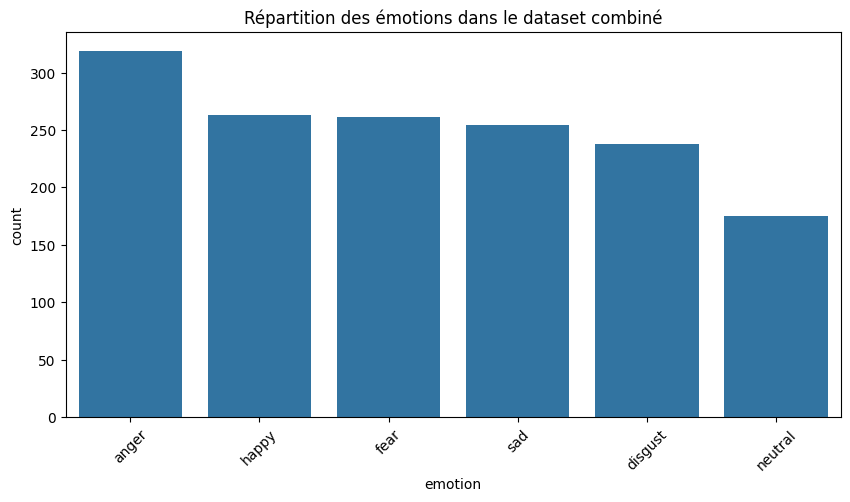

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index)
plt.title("Répartition des émotions dans le dataset combiné")
plt.xticks(rotation=45)
plt.show()


100%|██████████| 1510/1510 [00:03<00:00, 393.55it/s]


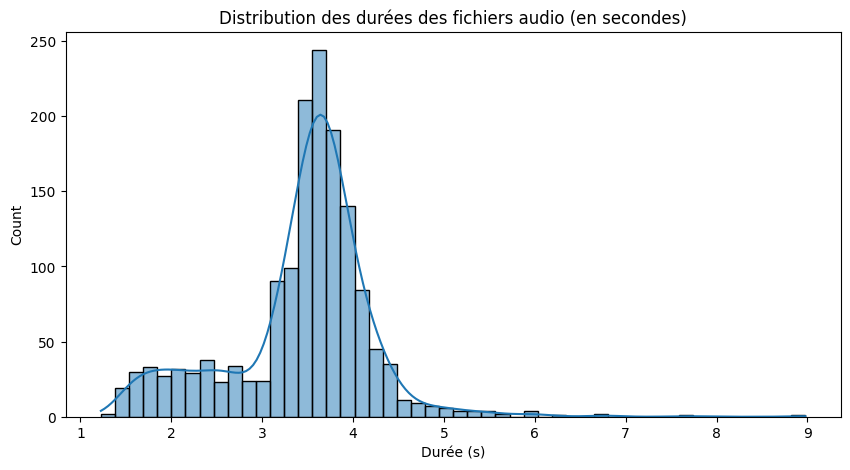

In [15]:
durations = []

for file in tqdm(df['file']):
    y, sr = librosa.load(file, sr=None)
    durations.append(len(y) / sr)

df['duration_sec'] = durations

# Affichage de la distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['duration_sec'], bins=50, kde=True)
plt.title("Distribution des durées des fichiers audio (en secondes)")
plt.xlabel("Durée (s)")
plt.show()


In [17]:
def extract_melspectrogram(file_path, sr=22050, n_fft=1024, hop_length=256, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)
    y = librosa.util.normalize(y)  # Normalisation
    spectrogram = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
    return spectrogram


In [23]:

# 2. Préparation des données
print("Extraction des mél-spectrogrammes...")
df['spectrogram'] = df['file'].apply(lambda x: extract_melspectrogram(x))


Extraction des mél-spectrogrammes...


In [19]:
sample = df.iloc[0]
mel_spec = extract_melspectrogram(sample['file'])
print(f"Shape du mél-spectrogramme : {mel_spec.shape}")

Shape du mél-spectrogramme : (128, 164)


100%|██████████| 100/100 [00:00<00:00, 123.37it/s]


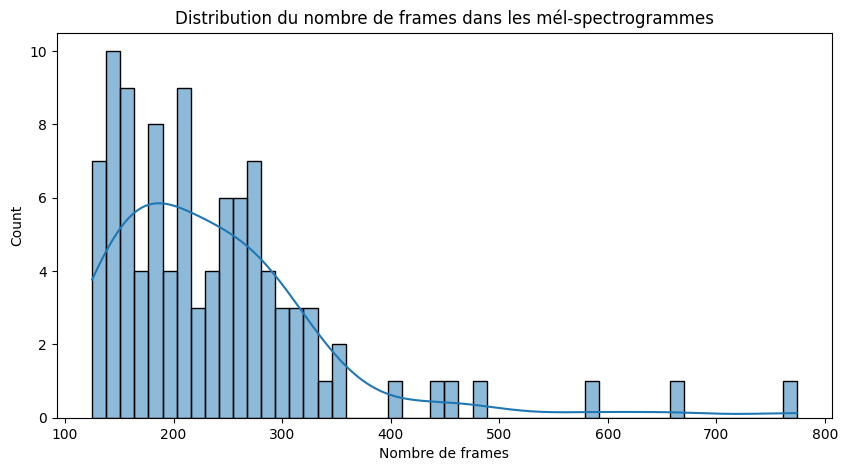

In [18]:
shapes = []

for file in tqdm(df['file'][:100]):  # Évite de tout charger pour l'instant
    mel = extract_melspectrogram(file)
    shapes.append(mel.shape[1])  # Le nombre de frames temporelles

# Visualisation
plt.figure(figsize=(10, 5))
sns.histplot(shapes, bins=50, kde=True)
plt.title("Distribution du nombre de frames dans les mél-spectrogrammes")
plt.xlabel("Nombre de frames")
plt.show()


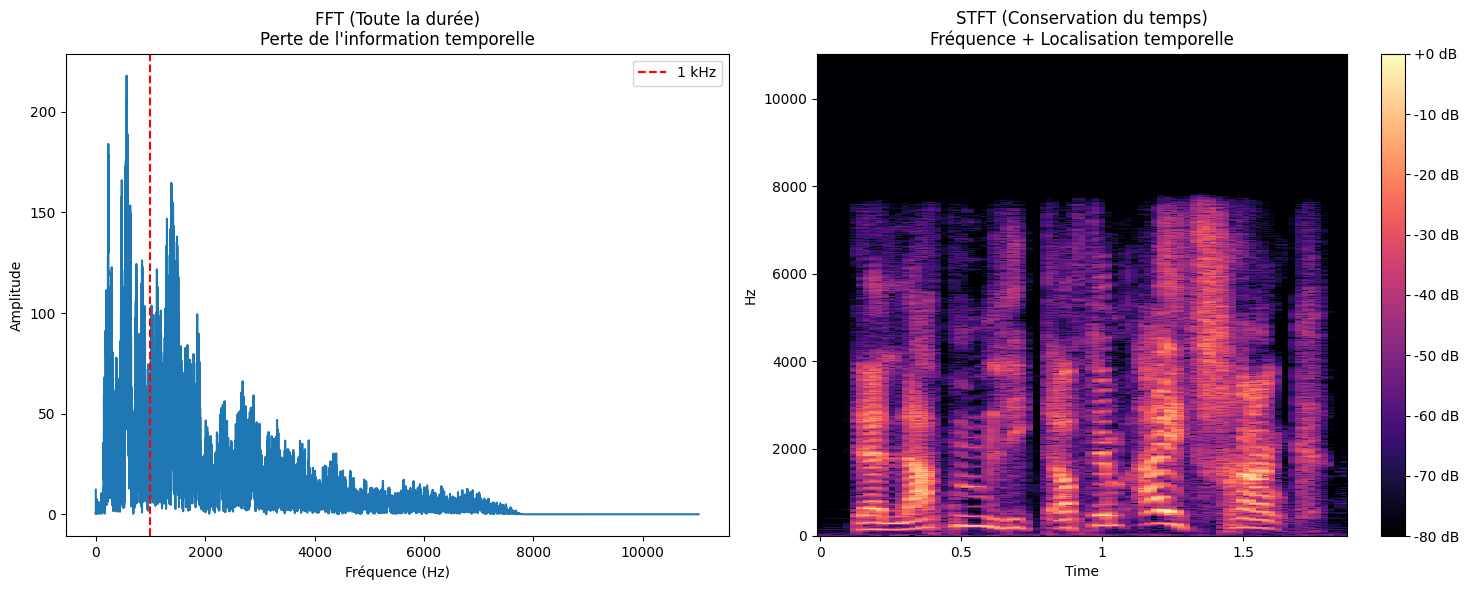

In [20]:
import matplotlib.pyplot as plt
import librosa.display

# Sélectionner un fichier audio avec une émotion claire (ex: colère)
sample_file = df[df['emotion'] == 'anger'].iloc[0]['file']
y, sr = librosa.load(sample_file, sr=22050)

# Paramètres communs
n_fft = 2048
hop_length = 512

# 1. Calculer la FFT (sur tout le signal)
fft = np.fft.fft(y)
fft_magnitude = np.abs(fft)
frequencies = np.fft.fftfreq(len(y), 1/sr)

# 2. Calculer la STFT
stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
stft_magnitude = np.abs(stft)

# 3. Visualisation
plt.figure(figsize=(15, 6))

# FFT (perte temporelle)
plt.subplot(1, 2, 1)
plt.plot(frequencies[:len(frequencies)//2], fft_magnitude[:len(fft)//2])
plt.title("FFT (Toute la durée)\nPerte de l'information temporelle")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.axvline(1000, color='r', linestyle='--', label='1 kHz')
plt.legend()

# STFT (conserve le temps)
plt.subplot(1, 2, 2)
librosa.display.specshow(librosa.amplitude_to_db(stft_magnitude, ref=np.max),
                        y_axis='hz', x_axis='time', sr=sr, hop_length=hop_length)
plt.title("STFT (Conservation du temps)\nFréquence + Localisation temporelle")
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

<h2 style="color:orange; font-family:Arial;">📐 Théorie : FFT vs. STFT</h2>

<p style="font-size:16px; font-family:Arial;">
Afin d'éviter la perte d'information temporelle lors de la conversion audio, nous n'avons pas utilisé la <strong style="color:#C0392B;">Fast Fourier Transform (FFT)</strong>, mais plutôt la <strong style="color:#27AE60;">Short-Time Fourier Transform (STFT)</strong>.
</p>

<h3 style="color:#2980B9; font-family:Arial;">🔹 FFT (Fast Fourier Transform)</h3>

<ul style="font-size:16px; font-family:Arial;">
  <li>Transforme <strong>l'ensemble du signal</strong> audio en une seule représentation fréquentielle.</li>
  <li><span style="color:#E74C3C;">Perte totale de l'information temporelle</span> : on sait quelles fréquences sont présentes, mais pas <em>quand</em> elles apparaissent.</li>
  <li>Convient mieux aux signaux stationnaires (constantes dans le temps).</li>
</ul>

<h3 style="color:#27AE60; font-family:Arial;">🔸 STFT (Short-Time Fourier Transform)</h3>

<ul style="font-size:16px; font-family:Arial;">
  <li>Découpe le signal en <strong>petites fenêtres temporelles</strong> (ex : 25 ms), puis applique la FFT à chaque fenêtre.</li>
  <li>Permet de <span style="color:#3498DB;">préserver l'information temporelle</span> tout en analysant les fréquences.</li>
  <li>Résultat : un <strong style="color:#8E44AD;">spectrogramme</strong> avec le <em>temps</em> sur l'axe X, et la <em>fréquence</em> sur l'axe Y.</li>
  <li>Idéal pour les signaux non stationnaires, comme la voix humaine.</li>
</ul>

<p style="font-size:16px; font-family:Arial;">
✅ Dans notre projet, l'utilisation de la STFT permet une <strong>analyse fine du contenu émotionnel</strong> à travers le temps, essentielle pour les tâches de reconnaissance d’émotions.
</p>


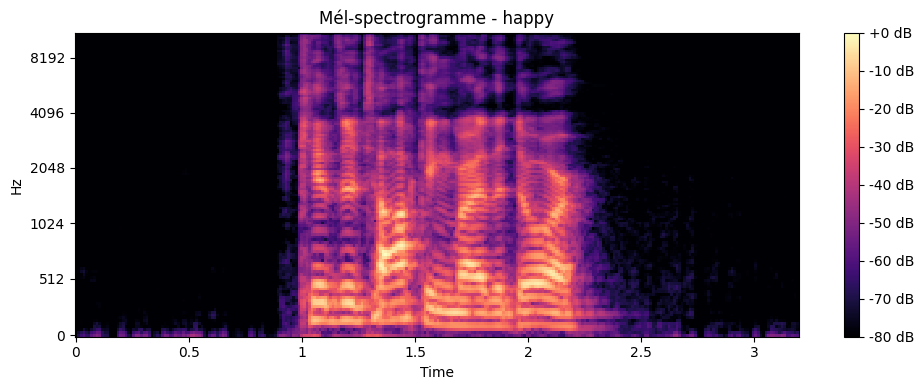

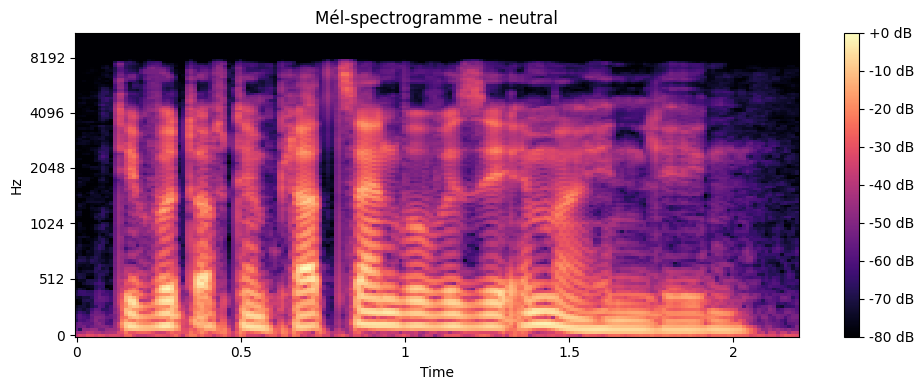

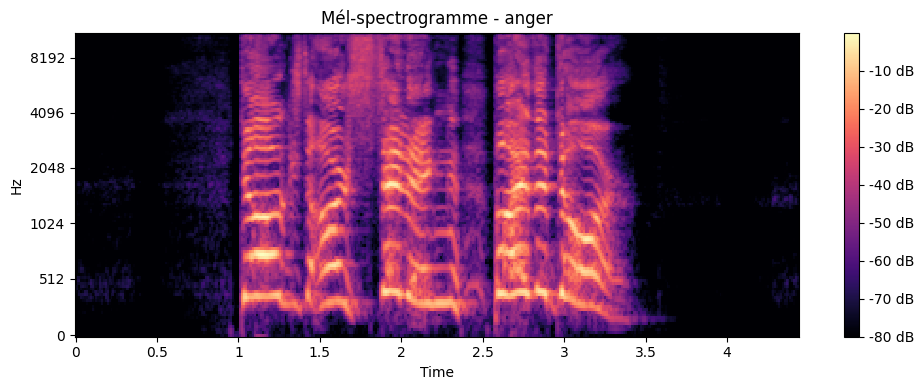

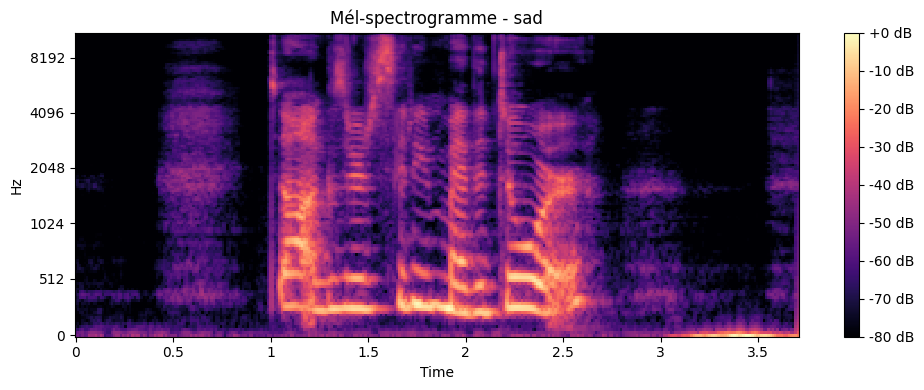

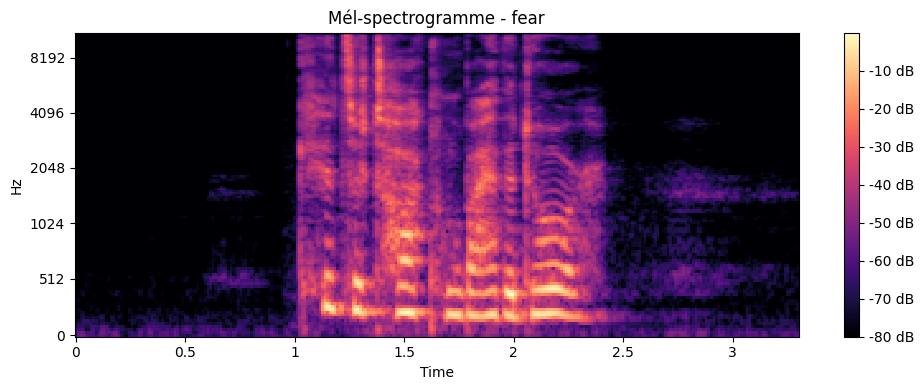

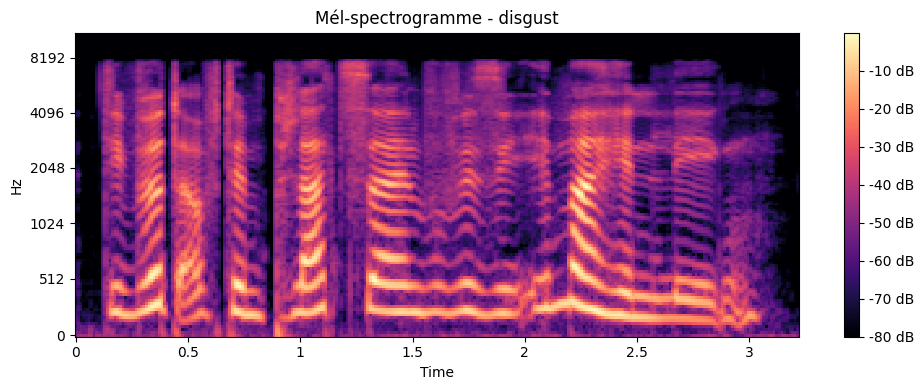

In [21]:
import random

emotions = df['emotion'].unique()

for emo in emotions:
    sample_file = df[df['emotion'] == emo].sample(1)['file'].values[0]
    mel = extract_melspectrogram(sample_file)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel, sr=22050, hop_length=256, x_axis='time', y_axis='mel')
    plt.title(f"Mél-spectrogramme - {emo}")
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()


<h1 style="color:cyan; font-family:Arial;">3 .Data Preprocessing & Modeling</h1>

<h3 style="color:red; font-family:Arial;"> Speech Emotion Recognition (SER)</h3>

<p style="font-size:16px; font-family:Arial;">
Dans cette étape, le but est de générer des <strong style="color:#8E44AD;">embeddings émotionnels</strong> à partir des fichiers audio convertis en <em>mel-spectrogrammes</em>.
</p>

<h3 style="color:#2980B9; font-family:Arial;">🔁 Processus de génération</h3>

<ul style="font-size:16px; font-family:Arial;">
  <li><strong>Entrée</strong> : Mel-spectrogrammes issus des fichiers audio <code>.wav</code>.</li>
  <li><strong>Modèle</strong> : <span style="color:#27AE60;">ResNet-50</span>, un réseau de neurones convolutif (CNN) utilisé pour extraire des <strong>vecteurs d’émotions</strong>.</li>
  <li><strong>Environnement</strong> : Implémentation sous <code>PyTorch</code>.</li>
</ul>

<h3 style="color:#E67E22; font-family:Arial;">🧾 Paramètres d'entraînement</h3>

<table style="font-family:Arial; font-size:16px; border-collapse:collapse;" border="1">
  <thead style="background-color:blue;">
    <tr>
      <th style="padding:8px;">Paramètre</th>
      <th style="padding:8px;">Valeur</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding:8px;">Labels (classes)</td>
      <td style="padding:8px;">Anger, Sadness, Happiness, Neutral, Fear, Disgust</td>
    </tr>
    <tr>
      <td style="padding:8px;">Optimiseur</td>
      <td style="padding:8px;"><code>Adam</code></td>
    </tr>
    <tr>
      <td style="padding:8px;">Taux d'apprentissage</td>
      <td style="padding:8px;"><code>1×10<sup>−4</sup></code></td>
    </tr>
    <tr>
      <td style="padding:8px;">Fonction de perte</td>
      <td style="padding:8px;"><code>CrossEntropyLoss</code></td>
    </tr>
    <tr>
      <td style="padding:8px;">Nombre d’époques</td>
      <td style="padding:8px;"><strong>30</strong></td>
    </tr>
  </tbody>
</table>

<p style="font-size:16px; font-family:Arial;">
Le modèle entraîne à classer les émotions à partir des spectrogrammes, puis utilise les couches cachées pour produire des <strong>vecteurs d'embeddings</strong> émotionnels réutilisables dans le modèle de génération (diffusion).
</p>
<img src="./CAPTURES/resrnet.png"></img>


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import cv2


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['emotion'])  # par ex. 'anger' -> 0, 'sad' -> 5, etc.


In [26]:
X = []  # images
y = []  # labels

for i in range(len(df)):
    spec = extract_melspectrogram(df.iloc[i]['file'])
    spec_resized = cv2.resize(spec, (224, 224))  # ou (128, 128) si CNN
    spec_3ch = np.stack([spec_resized]*3, axis=-1)  # pour ResNet50
    X.append(spec_3ch)
    y.append(df.iloc[i]['label'])

X = np.array(X)
y = np.array(y)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

# Séparation des données en train / val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Prétraitement ResNet50
X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)

# Définir le modèle ResNet50 (nouveau modèle model2)
base_model2 = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x2 = base_model2.output
x2 = GlobalAveragePooling2D()(x2)
x2 = Dense(128, activation='relu')(x2)
x2 = Dropout(0.5)(x2)
x2 = Dense(128, activation='relu')(x2)   
output2 = Dense(len(le.classes_), activation='softmax')(x2)
model2 = Model(inputs=base_model2.input, outputs=output2)


# Calcul des poids de classes
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

# Générateur d’augmentation de données
datagen = ImageDataGenerator(
    
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    vertical_flip=True,
    fill_mode='nearest'
)
datagen.fit(X_train)


# Compiler le modèle
optimizer = Adam(learning_rate=1e-4)
model2.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entraînement du modèle
model2.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    #X_train,y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    #callbacks=[early_stopping, reduce_lr],
    #class_weight=class_weights
)


Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 290s 7s/step - accuracy: 0.2192 - loss: 1.9012 - val_accuracy: 0.2285 - val_loss: 1.7791
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 257s 7s/step - accuracy: 0.3675 - loss: 1.5364 - val_accuracy: 0.3146 - val_loss: 1.6066
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 263s 7s/step - accuracy: 0.4683 - loss: 1.3117 - val_accuracy: 0.4636 - val_loss: 1.4201
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 272s 7s/step - accuracy: 0.5861 - loss: 1.0665 - val_accuracy: 0.4768 - val_loss: 1.3624
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 271s 7s/step - accuracy: 0.7041 - loss: 0.8372 - val_accuracy: 0.3079 - val_loss: 1.7244
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 276s 7s/step - accuracy: 0.7905 - loss: 0.6459 - val_accuracy: 0.4371 - val_loss: 1.6105
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 284s 7s/step - accuracy: 0.8726 - loss: 0.4146 - val_accuracy: 0.4503 - val_loss: 2.0298
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 281s 7s/step - accuracy: 0.9040 - loss: 0.3127 - val_accuracy: 0.3278 - v


<h2 style="color:cyan; font-family:Arial;">4 . Analyse de l'évolution de l'apprentissage du modèle</h2>


<p style="font-size:16px; font-family:Arial;">
Le modèle a été entraîné sur <strong>10 époques</strong> avec des métriques d’évaluation sur l’ensemble de validation à chaque itération. L'évolution des performances permet de déduire son comportement d’apprentissage.
</p>

<h3 style="color:#2980B9; font-family:Arial;">📊 Tendance globale</h3>
<ul style="font-size:16px; font-family:Arial;">
  <li><strong style="color:#27AE60;">Accuracy (train)</strong> : passe de <strong>0.22</strong> à <strong>0.92</strong>, montrant une très bonne capacité d’apprentissage.</li>
  <li><strong style="color:#E74C3C;">Accuracy (validation)</strong> : fluctue autour de <strong>0.32 à 0.47</strong> avec un pic à l'époque 4 (<code>0.4768</code>), indiquant une difficulté à généraliser.</li>
  <li><strong>Loss (train)</strong> : diminue régulièrement, signe que le modèle apprend efficacement sur les données d'entraînement.</li>
  <li><strong>Loss (validation)</strong> : reste élevée et instable, avec une montée notable à partir de l’époque 5 (jusqu’à <code>2.62</code>), suggérant un début de <span style="color:#E67E22;"><strong>surapprentissage</strong></span>.</li>
</ul>

<h3 style="color:#8E44AD; font-family:Arial;">🧠 Interprétation</h3>

<p style="font-size:16px; font-family:Arial;">
Le modèle montre une capacité remarquable à apprendre les données d'entraînement, atteignant une <strong>précision de 92.3%</strong> à la 10<sup>e</sup> époque. Cependant, la divergence entre les performances d’entraînement et de validation à partir de l’époque 5 indique un risque clair de <strong style="color:#E74C3C;">surapprentissage</strong>. Le modèle commence à "mémoriser" les données d'entraînement au lieu de généraliser.
</p>

<h3 style="color:#16A085; font-family:Arial;">✅ Recommandations</h3>
<ul style="font-size:16px; font-family:Arial;">
  <li>Mettre en place une stratégie de <strong>régularisation</strong> (ex: <code>Dropout</code>, <code>L2</code>).</li>
  <li>Introduire un <strong>early stopping</strong> pour stopper l’entraînement avant que le surapprentissage ne se manifeste.</li>
  <li>Augmenter la <strong>diversité des données</strong> via l'augmentation ou l'utilisation de données synthétiques générées (ex: par diffusion).</li>
    <li><span style="color:#E67E22;">🚀 L'entraînement est très lent</span> (environ 270 secondes par époque) : nous avons donc opté pour <strong style="color:#2980B9;">le déploiement du modèle sur GPU</strong> pour accélérer considérablement le processus d’apprentissage.</li>

</ul>


In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Vérifier la disponibilité du GPU
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))
print("TensorFlow utilise:", tf.test.gpu_device_name())

# Forcer l'utilisation du GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


GPUs disponibles : [<PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')>]
TensorFlow utilise : GPU NVIDIA GeForce RTX 2060 (14.0 GB VRAM allouée)


In [40]:
from tensorflow.keras import regularizers

# Remplacer votre modèle par une architecture plus adaptée
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:100]:  # Geler les premières couches
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = Dropout(0.5)(x)
output = Dense(len(le.classes_), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint



# Améliorer l'augmentation des données


# Ajouter plus de callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

# Paramètres recommandés
optimizer = Adam(learning_rate=10e-4)  # Réduire le learning rate

model.compile(optimizer=optimizer, 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
# Paramètres d'entraînement
epochs = 30  # Augmenter le nombre d'époques (early stopping interviendra si nécessaire)
batch_size = 16

# Entraînement du modèle avec augmentation de données et callbacks
history = model.fit(
    X_train, y_train,  # Utilisation du générateur d'augmentation
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=(X_val, y_val),
    epochs=epochs,
    callbacks=callbacks,  # Liste des callbacks définie précédemment
    class_weight=class_weights,  # Utilisation des poids de classe si déséquilibre
    verbose=1
)

Epoch 1/30
72/75 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.4677 - loss: 1.2952

75/75 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.4681 - loss: 1.2948 - val_accuracy: 0.2252 - val_loss: 38.3111 - learning_rate: 0.0010
Epoch 2/30
72/75 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5338 - loss: 1.2048

75/75 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.5336 - loss: 1.2054 - val_accuracy: 0.3278 - val_loss: 27.7020 - learning_rate: 0.0010
Epoch 3/30
72/75 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5426 - loss: 1.1658

75/75 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.5418 - loss: 1.1670 - val_accuracy: 0.3444 - val_loss: 4.8707 - learning_rate: 0.0010
Epoch 4/30
72/75 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5836 - loss: 1.0893

75/75 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.5828 - loss: 1.0897 - val_accuracy: 0.4636 - val_loss: 1.9141 - learning_rate: 0.0010
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.5881 - loss: 1.1033 - val_accuracy: 0.4702 - val_loss: 2.3930 - learning_rate: 0.0010
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.5922 - loss: 1.1069 - val_accuracy: 0.3013 - val_loss: 12.4144 - learning_rate: 0.0010
Epoch 7/30
72/75 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.6331 - loss: 0.9737

...

75/75 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.6966 - loss: 0.9276 - val_accuracy: 0.6689 - val_loss: 1.2404 - learning_rate: 0.0010
Epoch 10/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.6658 - loss: 0.9828 - val_accuracy: 0.5662 - val_loss: 1.8518 - learning_rate: 0.0010
Epoch 11/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.7229 - loss: 0.8325 - val_accuracy: 0.6126 - val_loss: 1.4942 - learning_rate: 0.0010
Epoch 12/30
72/75 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7547 - loss: 0.7961

75/75 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.7550 - loss: 0.7958 - val_accuracy: 0.6887 - val_loss: 1.0463 - learning_rate: 0.0010
Epoch 13/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.8132 - loss: 0.6425 - val_accuracy: 0.6192 - val_loss: 1.7060 - learning_rate: 0.0010
Epoch 14/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8033 - loss: 0.7352 - val_accuracy: 0.6457 - val_loss: 1.6028 - learning_rate: 0.0010
Epoch 15/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8147 - loss: 0.6111 - val_accuracy: 0.6589 - val_loss: 1.1385 - learning_rate: 0.0010
Epoch 16/30
72/75 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9126 - loss: 0.4680

75/75 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9118 - loss: 0.4690 - val_accuracy: 0.7119 - val_loss: 0.9978 - learning_rate: 2.0000e-04
Epoch 17/30
72/75 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9140 - loss: 0.4071

75/75 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.9139 - loss: 0.4072 - val_accuracy: 0.7384 - val_loss: 0.9762 - learning_rate: 2.0000e-04
Epoch 18/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9358 - loss: 0.3785 - val_accuracy: 0.7351 - val_loss: 1.0318 - learning_rate: 2.0000e-04
Epoch 19/30
72/75 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9257 - loss: 0.3507

75/75 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9255 - loss: 0.3516 - val_accuracy: 0.7285 - val_loss: 0.9684 - learning_rate: 2.0000e-04
Epoch 20/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9324 - loss: 0.3487 - val_accuracy: 0.7450 - val_loss: 0.9714 - learning_rate: 2.0000e-04
Epoch 21/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9339 - loss: 0.3632 - val_accuracy: 0.7086 - val_loss: 1.0297 - learning_rate: 2.0000e-04
Epoch 22/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9535 - loss: 0.3206 - val_accuracy: 0.7384 - val_loss: 1.0526 - learning_rate: 2.0000e-04
Epoch 23/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9603 - loss: 0.2828 - val_accuracy: 0.7185 - val_loss: 1.0642 - learning_rate: 4.0000e-05
Epoch 24/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9745 - loss: 0.2393 - val_accuracy: 0.7318 - val_loss: 1.0733 - learning_rate: 4.0000e-05


<h2 style="color:blue; font-family:Arial;">🚀 Résultats d'un second entraînement plus performant</h2>

<p style="font-size:16px; font-family:Arial;">
Ce second modèle montre une progression claire en termes de performances, avec une précision d'entraînement dépassant les <strong style="color:#27AE60;">95%</strong> et une précision de validation atteignant <strong style="color:#2980B9;">74.5%</strong> à l'époque 20.
</p>

<h3 style="color:#2980B9; font-family:Arial;">📈 Amélioration constatée</h3>

<ul style="font-size:16px; font-family:Arial;">
  <li>Progression de la <strong>val_accuracy</strong> de <code>22%</code> (époque 1) à <strong style="color:#27AE60;">73.8%</strong> (époque 22).</li>
  <li>Diminution constante de la <strong>val_loss</strong>, atteignant <strong><code>0.9684</code></strong>.</li>
  <li>Stabilisation du modèle vers l’époque 20–23.</li>
  <li>Utilisation efficace du <strong style="color:#16A085;">scheduler de learning rate</strong> pour affiner la convergence.</li>
</ul>

<h3 style="color:#8E44AD; font-family:Arial;">🎯 Conclusion</h3>

<p style="font-size:16px; font-family:Arial;">
Ce modèle est plus performant et mieux généralisé que le précédent. Il constitue une base solide pour une reconnaissance vocale émotionnelle fiable.
</p>

<h3 style="color:#E67E22; font-family:Arial;">🧪 Recommandations pour l'amélioration de la qualité des données audio</h3>

<ul style="font-size:16px; font-family:Arial;">
  <li>Pour optimiser encore la clarté émotionnelle des enregistrements vocaux, il est recommandé d’utiliser un <strong style="color:#8E44AD;">modèle de diffusion</strong>.</li>
  <li>Ce modèle permet de <strong>générer des spectrogrammes audio synthétiques</strong> de meilleure qualité à partir d’un bruit initial, tout en injectant les <strong>embeddings émotionnels</strong> extraits (via ResNet-50).</li>
  <li>Les spectrogrammes générés peuvent ensuite être validés par un modèle de classification pour <strong>vérifier leur pertinence émotionnelle</strong>.</li>
  <li>Cette approche <span style="color:#27AE60;"><strong>améliore la diversité et la qualité du jeu de données</strong></span>, et donc les performances globales du modèle.</li>
</ul>



------------------------------------------------
<table style="width:100%; font-family:Arial; border-collapse:collapse; border:1px solid #ccc;">
  <tr>
    <td style="padding:16px; border:1px solid #ccc;">
      <h2 style="color:cyan; font-family:Arial;">5. Évaluation des métriques du modèle</h2>
      <p style="font-size:16px; font-family:Arial; margin-top:10px;">
        Cette section présente les résultats détaillés du modèle : 
        <strong>matrice de confusion</strong>, 
        <strong>précision</strong>, 
        <strong>recall</strong>, 
        <strong>F1-score</strong>, 
        <strong>support</strong> pour chaque label, ainsi que les 
        <strong>courbes d’évolution de la loss et de l’accuracy</strong>.
      </p>
    </td>
  </tr>
</table>



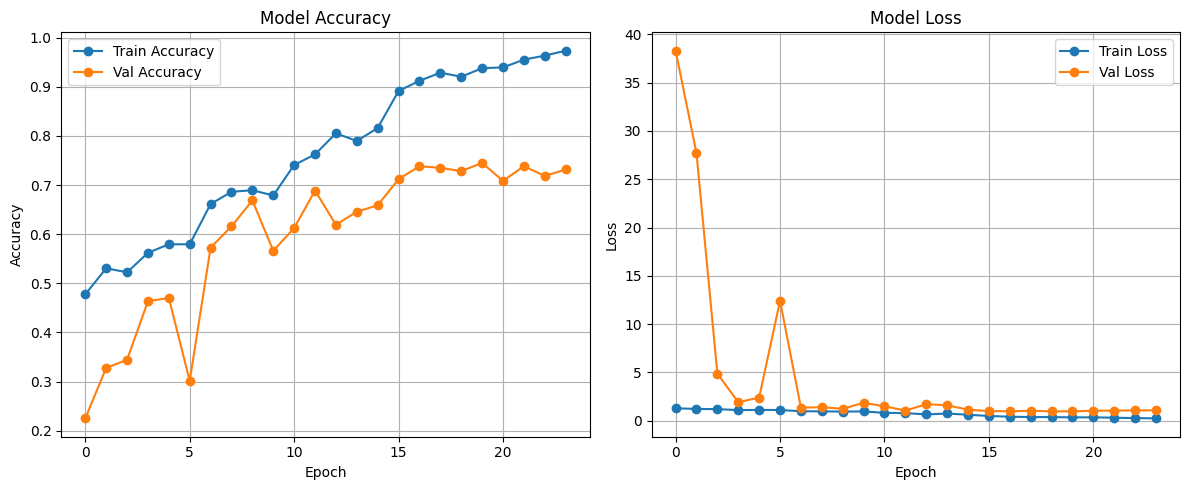

In [65]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
              precision    recall  f1-score   support

       anger       0.81      0.81      0.81        64
     disgust       0.81      0.79      0.80        48
        fear       0.78      0.56      0.65        52
       happy       0.46      0.65      0.54        52
     neutral       0.89      0.97      0.93        35
         sad       0.79      0.65      0.71        51

    accuracy                           0.73       302
   macro avg       0.76      0.74      0.74       302
weighted avg       0.75      0.73      0.73       302



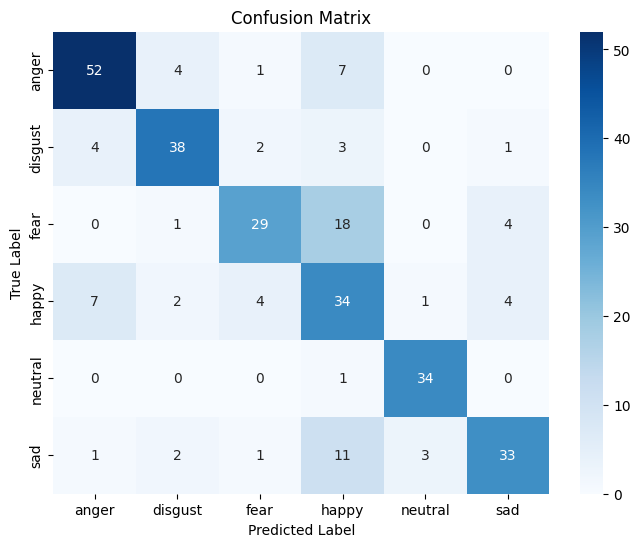

In [69]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prédictions
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Inverser les labels si tu as utilisé un LabelEncoder
# Remplace "label_encoder" par le nom réel de ton encoder
class_names = le.inverse_transform(np.unique(y_val))

# Affichage du rapport de classification avec noms des classes
print(classification_report(y_val, y_pred_classes, target_names=class_names))

# Matrice de confusion avec noms de classes
cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


------------------------------------------------

<h2 style="color:white; font-family:Arial;"> Évaluation sur des données hors traitement</h2>


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Classes disponibles: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad']

Prédiction: happy (Confiance: 81.70%)


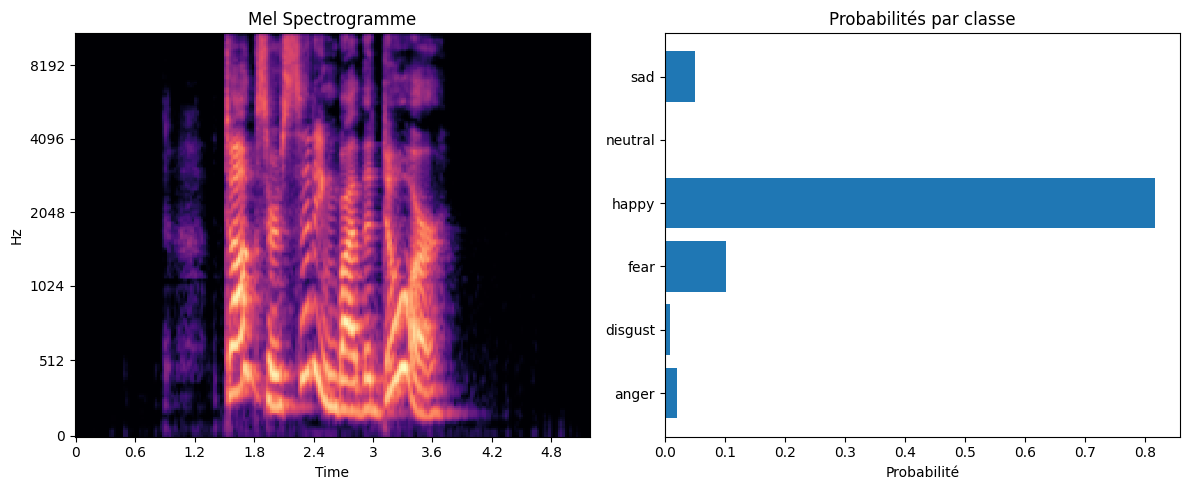


Écoutez l'échantillon audio :


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

# Chemin vers votre fichier audio à tester
test_file = "test/happiness.wav"  # Remplacez par votre chemin

# Fonction de prétraitement
def preprocess_audio(file_path):
    y, sr = librosa.load(file_path, sr=22050)
    y = librosa.util.normalize(y)
    spectrogram = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=128
    )
    spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
    spectrogram_resized = cv2.resize(spectrogram, (224, 224))
    spectrogram_3ch = np.stack([spectrogram_resized]*3, axis=-1)
    spectrogram_3ch = np.expand_dims(spectrogram_3ch, axis=0)
    spectrogram_3ch = preprocess_input(spectrogram_3ch)
    return spectrogram_3ch

# Prétraiter l'audio
preprocessed_audio = preprocess_audio(test_file)

# Faire la prédiction
predictions = model.predict(preprocessed_audio)
predicted_class_idx = np.argmax(predictions[0])
confidence = np.max(predictions[0])

# Décoder la prédiction avec le LabelEncoder
predicted_emotion = le.inverse_transform([predicted_class_idx])[0]

# Afficher les classes disponibles
print("Classes disponibles:", list(le.classes_))

# Afficher les résultats
print(f"\nPrédiction: {predicted_emotion} (Confiance: {confidence:.2%})")

# Visualisation détaillée
plt.figure(figsize=(12, 5))

# Spectrogramme
plt.subplot(1, 2, 1)
librosa.display.specshow(preprocessed_audio[0,:,:,0], x_axis='time', y_axis='mel')
plt.title('Mel Spectrogramme')

# Probabilités par classe
plt.subplot(1, 2, 2)
classes = le.classes_
probabilities = predictions[0]
plt.barh(classes, probabilities)
plt.title('Probabilités par classe')
plt.xlabel('Probabilité')
plt.tight_layout()
plt.show()

# Écouter l'audio
print("\nÉcoutez l'échantillon audio :")
Audio(test_file)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step

Prédiction: sad (Confiance: 84.19%)


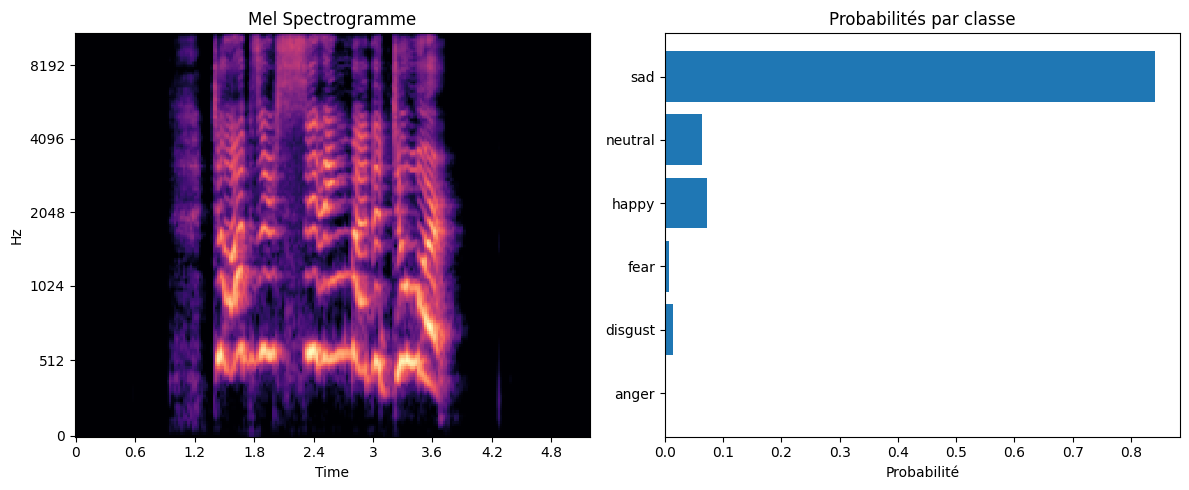


Écoutez l'échantillon audio :


In [63]:
test_file = "test/sad.wav"  # Remplacez par votre chemin
preprocessed_audio = preprocess_audio(test_file)

# Faire la prédiction
predictions = loaded_model.predict(preprocessed_audio)
predicted_class_idx = np.argmax(predictions[0])
confidence = np.max(predictions[0])

# Décoder la prédiction avec le LabelEncoder
predicted_emotion = loaded_le.inverse_transform([predicted_class_idx])[0]
# Afficher les résultats
print(f"\nPrédiction: {predicted_emotion} (Confiance: {confidence:.2%})")

# Visualisation détaillée
plt.figure(figsize=(12, 5))

# Spectrogramme
plt.subplot(1, 2, 1)
librosa.display.specshow(preprocessed_audio[0,:,:,0], x_axis='time', y_axis='mel')
plt.title('Mel Spectrogramme')

# Probabilités par classe
plt.subplot(1, 2, 2)
classes = le.classes_
probabilities = predictions[0]
plt.barh(classes, probabilities)
plt.title('Probabilités par classe')
plt.xlabel('Probabilité')
plt.tight_layout()
plt.show()

# Écouter l'audio
print("\nÉcoutez l'échantillon audio :")
Audio(test_file)

<h2 style="color:cyan; font-family:Arial;">6. Sauvegarde du modèle et l'encoder</h2>


In [55]:
from joblib import dump
from tensorflow.keras.models import save_model

# 1. Sauvegarde du modèle Keras au format .h5
save_model(model, 'savefinal/emotion_model.h5')

# 2. Sauvegarde du LabelEncoder avec joblib
dump(le, 'savefinal/label_encoder.joblib') 

print("Modèle et LabelEncoder sauvegardés avec succès")

Modèle et LabelEncoder sauvegardés avec succès


In [56]:
from joblib import load
from tensorflow.keras.models import load_model

# 1. Charger le modèle Keras
loaded_model = load_model('savefinal/emotion_model.h5')

# 2. Charger le LabelEncoder
loaded_le = load('savefinal/label_encoder.joblib')

print("Modèle et LabelEncoder chargés avec succès")

Modèle et LabelEncoder chargés avec succès
